In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

print("PyTorch version:", torch.__version__)
print("All libraries imported successfully.")

PyTorch version: 2.14.0+cpu
All libraries imported successfully.


In [2]:
texts = [
    "I absolutely loved this product",
    "The service was excellent and very helpful",
    "Amazing experience and great quality",
    "I am very happy with this purchase",
    "The product works perfectly",
    "Customer support was friendly and helpful",
    "This is one of the best products I bought",
    "Very satisfied with the service",
    "The quality is fantastic",
    "I would definitely recommend this product",
    
    "I hated this product",
    "The service was terrible",
    "Very poor quality and disappointing",
    "I am unhappy with this purchase",
    "The product stopped working quickly",
    "Customer support was rude and unhelpful",
    "This is one of the worst products I bought",
    "Very disappointed with the service",
    "The quality is awful",
    "I would not recommend this product"
]

labels = [
    1, 1, 1, 1, 1,
    1, 1, 1, 1, 1,
    0, 0, 0, 0, 0,
    0, 0, 0, 0, 0
]

data = pd.DataFrame({
    "text": texts,
    "label": labels
})

print("Dataset shape:", data.shape)
data.head()

Dataset shape: (20, 2)


,text,label
0,I absolutely loved this product,1
1,The service was excellent and very helpful,1
2,Amazing experience and great quality,1
3,I am very happy with this purchase,1
4,The product works perfectly,1


In [3]:
X_train_text, X_test_text, y_train, y_test = train_test_split(
    data["text"],
    data["label"],
    test_size=0.2,
    random_state=42,
    stratify=data["label"]
)

print("Training samples:", len(X_train_text))
print("Testing samples:", len(X_test_text))

Training samples: 16
Testing samples: 4


In [4]:
tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    ngram_range=(1, 2),
    max_features=1000
)

X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf = tfidf.transform(X_test_text)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (16, 54)
Testing TF-IDF shape: (4, 54)


In [5]:
X_train_tensor = torch.tensor(
    X_train_tfidf.toarray(),
    dtype=torch.float32
)

X_test_tensor = torch.tensor(
    X_test_tfidf.toarray(),
    dtype=torch.float32
)

y_train_tensor = torch.tensor(
    np.array(y_train),
    dtype=torch.long
)

y_test_tensor = torch.tensor(
    np.array(y_test),
    dtype=torch.long
)

print("Tensor conversion completed.")

Tensor conversion completed.


In [6]:
train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

test_dataset = TensorDataset(
    X_test_tensor,
    y_test_tensor
)

train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=4,
    shuffle=False
)

print("DataLoaders created.")

DataLoaders created.


In [7]:
class SentimentNN(nn.Module):
    def __init__(self, input_size):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(64, 2)
        )

    def forward(self, x):
        return self.network(x)


input_size = X_train_tensor.shape[1]

model = SentimentNN(input_size)

print(model)

SentimentNN(
  (network): Sequential(
    (0): Linear(in_features=54, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=2, bias=True)
  )
)


In [8]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Loss function and optimizer ready.")

Loss function and optimizer ready.


In [9]:
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train_tensor,
    y_train_tensor,
    test_size=0.2,
    random_state=42,
    stratify=y_train_tensor
)

train_dataset = TensorDataset(
    X_train_final,
    y_train_final
)

val_dataset = TensorDataset(
    X_val,
    y_val
)

train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=4,
    shuffle=False
)

print("Training samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))

Training samples: 12
Validation samples: 4


In [10]:
num_epochs = 100
patience = 10

best_val_loss = float("inf")
patience_counter = 0

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

best_model_state = None

for epoch in range(num_epochs):

    # Training
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in train_loader:

        optimizer.zero_grad()

        outputs = model(inputs)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item() * inputs.size(0)

        predictions = outputs.argmax(dim=1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_accuracy = correct / total

    # Validation
    model.eval()

    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for inputs, labels in val_loader:

            outputs = model(inputs)

            loss = criterion(outputs, labels)

            val_running_loss += loss.item() * inputs.size(0)

            predictions = outputs.argmax(dim=1)

            val_correct += (predictions == labels).sum().item()
            val_total += labels.size(0)

    val_loss = val_running_loss / val_total
    val_accuracy = val_correct / val_total

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)

    print(
        f"Epoch {epoch + 1:03d} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Train Acc: {train_accuracy:.3f} | "
        f"Val Acc: {val_accuracy:.3f}"
    )

    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0

        best_model_state = {
            key: value.clone()
            for key, value in model.state_dict().items()
        }

    else:
        patience_counter += 1

        if patience_counter >= patience:
            print("Early stopping triggered.")
            break

Epoch 001 | Train Loss: 0.8141 | Val Loss: 0.6956 | Train Acc: 0.417 | Val Acc: 0.500
Epoch 002 | Train Loss: 0.7010 | Val Loss: 0.7003 | Train Acc: 0.500 | Val Acc: 0.500
Epoch 003 | Train Loss: 0.7084 | Val Loss: 0.7064 | Train Acc: 0.500 | Val Acc: 0.500
Epoch 004 | Train Loss: 0.5339 | Val Loss: 0.7120 | Train Acc: 0.667 | Val Acc: 0.500
Epoch 005 | Train Loss: 0.6312 | Val Loss: 0.7141 | Train Acc: 0.667 | Val Acc: 0.500
Epoch 006 | Train Loss: 0.5519 | Val Loss: 0.7163 | Train Acc: 0.833 | Val Acc: 0.500
Epoch 007 | Train Loss: 0.5877 | Val Loss: 0.7258 | Train Acc: 0.833 | Val Acc: 0.500
Epoch 008 | Train Loss: 0.4303 | Val Loss: 0.7273 | Train Acc: 0.917 | Val Acc: 0.500
Epoch 009 | Train Loss: 0.3223 | Val Loss: 0.7277 | Train Acc: 1.000 | Val Acc: 0.500
Epoch 010 | Train Loss: 0.3976 | Val Loss: 0.7314 | Train Acc: 1.000 | Val Acc: 0.500
Epoch 011 | Train Loss: 0.5256 | Val Loss: 0.7359 | Train Acc: 0.833 | Val Acc: 0.500
Early stopping triggered.


In [11]:
model.load_state_dict(best_model_state)

print("Best validation model restored.")

Best validation model restored.


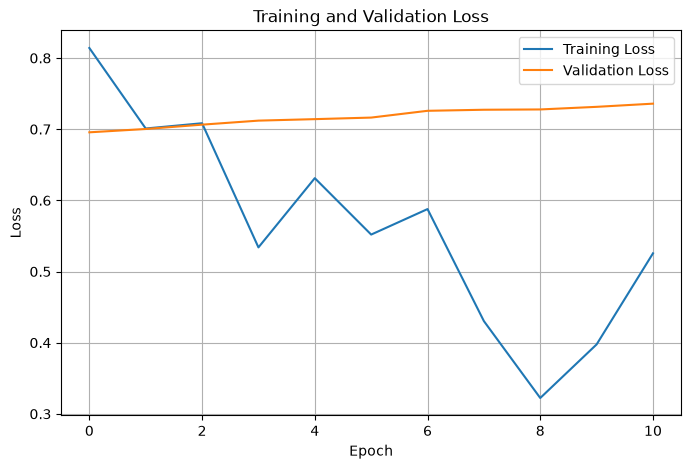

In [12]:
plt.figure(figsize=(8, 5))

plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid()

plt.show()

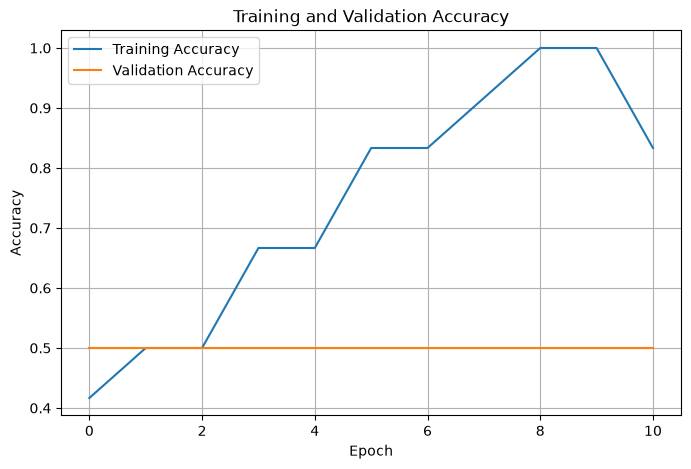

In [14]:
plt.figure(figsize=(8, 5))

plt.plot(train_accuracies, label="Training Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid()

plt.show()

In [15]:
model.eval()

with torch.no_grad():

    test_outputs = model(X_test_tensor)

    test_probabilities = torch.softmax(
        test_outputs,
        dim=1
    )

    test_predictions = test_outputs.argmax(dim=1)

test_accuracy = (
    test_predictions == y_test_tensor
).float().mean().item()

print(f"Test Accuracy: {test_accuracy:.3f}")

Test Accuracy: 0.500


In [16]:
test_predictions_np = test_predictions.numpy()
y_test_np = y_test_tensor.numpy()

print(
    classification_report(
        y_test_np,
        test_predictions_np,
        target_names=["Negative", "Positive"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

    Negative       0.50      1.00      0.67         2
    Positive       0.00      0.00      0.00         2

    accuracy                           0.50         4
   macro avg       0.25      0.50      0.33         4
weighted avg       0.25      0.50      0.33         4



In [17]:
sample_texts = [
    "The product quality is excellent and I love it",
    "This service was terrible and disappointing",
    "I am very happy with the purchase",
    "The product is awful and does not work"
]

sample_tfidf = tfidf.transform(sample_texts)

sample_tensor = torch.tensor(
    sample_tfidf.toarray(),
    dtype=torch.float32
)

model.eval()

with torch.no_grad():

    outputs = model(sample_tensor)

    probabilities = torch.softmax(
        outputs,
        dim=1
    )

    predictions = outputs.argmax(dim=1)

for text, prediction, probability in zip(
    sample_texts,
    predictions,
    probabilities
):

    predicted_label = (
        "Positive" if prediction.item() == 1
        else "Negative"
    )

    confidence = probability[prediction].item()

    print(f"Text: {text}")
    print(f"Prediction: {predicted_label}")
    print(f"Confidence: {confidence:.2%}")
    print("-" * 60)

Text: The product quality is excellent and I love it
Prediction: Negative
Confidence: 53.76%
------------------------------------------------------------
Text: This service was terrible and disappointing
Prediction: Negative
Confidence: 52.68%
------------------------------------------------------------
Text: I am very happy with the purchase
Prediction: Negative
Confidence: 53.74%
------------------------------------------------------------
Text: The product is awful and does not work
Prediction: Negative
Confidence: 54.08%
------------------------------------------------------------


In [18]:
cm = confusion_matrix(
    y_test_np,
    test_predictions_np
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[2 0]
 [2 0]]


# Final Summary

## NLP Pipeline
A sentiment classification pipeline was developed using TF-IDF text vectorization and a PyTorch neural network.

## Neural Network
The model contains:
- Fully connected layers
- Batch Normalization
- ReLU activation
- Dropout regularization
- Output classification layer

## Training
The model was trained using:
- Cross-entropy loss
- Adam optimizer
- Training and validation datasets
- Early stopping based on validation loss

## Evaluation
The model was evaluated on unseen test data using:
- Accuracy
- Precision
- Recall
- F1-score
- Confusion matrix

## Training Curves
Training and validation loss and accuracy curves were plotted to observe model convergence.

## Sample Inference
The trained model was tested on unseen text samples and produced:
- Predicted sentiment
- Classification confidence

## Limitation
The dataset used in this demonstration is small and manually constructed for an internship demonstration. Therefore, the model should not be considered production-ready without a larger, representative dataset.